In [17]:
import os, re, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.optimize import curve_fit

h1   = pd.read_csv("HarrisPartI.csv")
h3   = pd.read_csv("HarrisPartIII.csv")

# trying out this output folder type thing. 
OUT = "ROToutput"; os.makedirs(OUT, exist_ok=True)

In [18]:
h1.head()

,ID,Name,RA,DEC,L,B,R_Sun,R_gc,X,Y,Z
0,NGC 104,47 Tuc,00:24:05.67,-72:04:52.6,305.89,-44.89,4.5,7.4,1.9,-2.6,-3.1
1,NGC 288,NaN,00:52:45.24,-26:34:57.4,152.30,-89.38,8.9,12.0,-0.1,0.0,-8.9
2,NGC 362,NaN,01:03:14.26,-70:50:55.6,301.53,-46.25,8.6,9.4,3.1,-5.1,-6.2
3,Whiting 1,NaN,02:02:57,-03:15:10,161.22,-60.76,30.1,34.5,-13.9,4.7,-26.3
4,NGC 1261,NaN,03:12:16.21,-55:12:58.4,270.54,-52.12,16.3,18.1,0.1,-10.0,-12.9


In [19]:
h3.head()

,ID,v_r,v_r_e,v_LSR,sig_v,sig_v_e,c,r_c,r_h,mu_V,rho_0,lg_tc,lg_th
0,NGC 104,-18.0,0.1,-26.7,11.0,0.3,2.07,0.36,3.17,14.38,4.88,7.84,9.55
1,NGC 288,-45.4,0.2,-51.9,2.9,0.3,0.99,1.35,2.23,20.05,1.78,8.99,9.32
2,NGC 362,223.5,0.5,214.0,6.4,0.3,1.76,0.18,0.82,14.80,4.74,7.76,8.93
3,Whiting 1,-130.6,1.8,-138.1,NaN,NaN,0.55,0.25,0.22,NaN,NaN,NaN,7.93
4,NGC 1261,68.2,4.6,54.9,NaN,NaN,1.16,0.35,0.68,17.73,2.99,8.59,9.12


Merged rows with L & a velocity: 143
Using MAD threshold: ±126.2 km/s
Sinusoidal fit: v0=-5.4, A=-122.8, L0=2.6


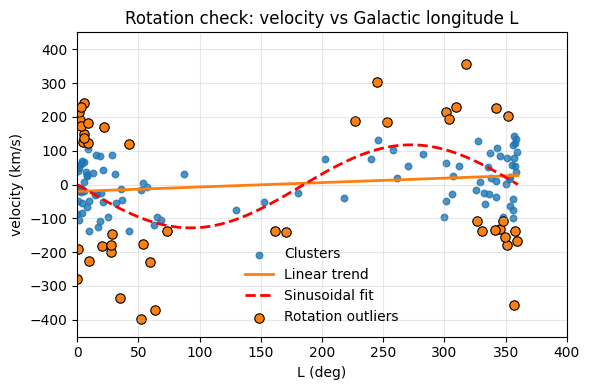

,Name,L,vel,v_fit,v_resid
58,NaN,0.13,-279.1,-20.341775,-258.758225
104,NaN,0.20,-189.4,-20.332632,-169.067368
97,NaN,1.14,214.9,-20.209857,235.109857
83,NaN,2.10,190.2,-20.084469,210.284469
117,M 70,2.85,227.8,-19.986509,247.786509
126,NaN,3.39,172.5,-19.915979,192.415979
65,NaN,4.90,126.3,-19.718754,146.018754
64,M 9,5.54,239.8,-19.635162,259.435162
119,M 54,5.61,149.2,-19.626019,168.826019
130,NaN,5.76,136.2,-19.606427,155.806427


slope = 0.131 km/s per deg, intercept = -20.4
Pearson r = 0.14, p = 8.981e-02


In [20]:
# === Rotation analysis: merge Harris I (L) with Harris III (velocities) ===

# Ensure OUT exists (if not already created above)
try:
    OUT
except NameError:
    OUT = "ROToutput"
os.makedirs(OUT, exist_ok=True)

# 1) Merge on ID. (working)
df_rot = (
    h1[["ID", "Name", "L", "B", "R_Sun", "R_gc"]]
    .merge(h3[["ID", "v_r", "v_LSR"]], on="ID", how="inner")
    .copy()
)

# 2) Build a single velocity column: prefer v_LSR if present, else v_r
df_rot["vel"] = df_rot["v_LSR"].where(df_rot["v_LSR"].notna(), df_rot["v_r"])
df_rot = df_rot.dropna(subset=["L", "vel"]).reset_index(drop=True)

print(f"Merged rows with L & a velocity: {len(df_rot)}")
if len(df_rot) == 0:
    raise ValueError("After merging, no rows have both L and (v_LSR or v_r). Check your columns/NaNs.")

# 3) Fit a simple linear rotation model: vel ≈ a + b * L
coef = np.polyfit(df_rot["L"].values, df_rot["vel"].values, 1)
fit = np.poly1d(coef)
df_rot["v_fit"] = fit(df_rot["L"].values)
df_rot["v_resid"] = df_rot["vel"].values - df_rot["v_fit"].values

# 4) Robust outlier threshold using MAD
resid = df_rot["v_resid"]
mad = (resid - resid.median()).abs().median()
thr = 1.5 * mad if mad > 0 else resid.abs().quantile(0.9)
df_rot["rot_outlier"] = df_rot["v_resid"].abs() > thr
print(f"Using {'MAD' if mad>0 else 'P90'} threshold: ±{thr:.1f} km/s")



# 5) Plot: linear + sinusoidal rotation fits together
from scipy.optimize import curve_fit

# Fit the sinusoidal model
def v_sin(L_deg, v0, A, L0):
    L = np.radians(L_deg)
    return v0 + A * np.sin(L - np.radians(L0))

# Use linear fit slope/intercept as part of initial guess
p0 = [coef[1], np.std(df_rot["vel"]), 0]  # v0 ≈ intercept, amplitude ≈ std(vel)
popt, _ = curve_fit(v_sin, df_rot["L"], df_rot["vel"], p0=p0, maxfev=10000)
df_rot["v_sin"] = v_sin(df_rot["L"], *popt)
print(f"Sinusoidal fit: v0={popt[0]:.1f}, A={popt[1]:.1f}, L0={popt[2]:.1f}")

# Plot both fits on the same graph
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(df_rot["L"], df_rot["vel"], s=22, alpha=0.8, label="Clusters")

Lgrid = np.linspace(0, 360, 360)
ax.plot(Lgrid, fit(Lgrid), "C1-", lw=2, label="Linear trend")
ax.plot(Lgrid, v_sin(Lgrid, *popt), "r--", lw=2, label="Sinusoidal fit")

# Highlight rotation outliers
oo = df_rot["rot_outlier"]
ax.scatter(df_rot.loc[oo, "L"], df_rot.loc[oo, "vel"],
           s=46, edgecolor="k", linewidth=0.8, label="Rotation outliers")

ax.set_xlim(0, 400)
ax.set_ylim(-450, 450)
ax.set_xlabel("L (deg)")
ax.set_ylabel("velocity (km/s)")
ax.set_title("Rotation check: velocity vs Galactic longitude L")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT}/Rotation_combined_linear_sinusoidal.png", dpi=300, bbox_inches="tight")
plt.show()


# 6) Compact table of rotation outliers
name_col = next((c for c in ["Name","ID","key","Cluster","name","cluster"] if c in df_rot.columns), None)
cols = [c for c in [name_col, "L", "vel", "v_fit", "v_resid"] if c is not None]
display(df_rot.loc[oo, cols].sort_values("L"))

r, p = stats.pearsonr(df_rot["L"], df_rot["vel"])
print(f"slope = {coef[0]:.3f} km/s per deg, intercept = {coef[1]:.1f}")
print(f"Pearson r = {r:.2f}, p = {p:.3e}")

from scipy.optimize import curve_fit
def v_sin(L_deg, v0, A, L0):
    L = np.radians(L_deg)
    return v0 + A * np.sin(L - np.radians(L0))

### Note on the Sinusoidal Rotation Model

The velocity–longitude relation for globular clusters can be approximated by a sinusoidal pattern because of how the Galaxy’s rotation projects along our line of sight.

When we plot each cluster’s line-of-sight velocity against Galactic longitude ($L$), the component of the circular rotation varies as $\sin(L - L_0)$.  
This is the same geometric effect that causes a sine-like curve in the classical Oort rotation diagram.

By fitting a function of the form:
$$
v(L) = v_0 + A \sin(L - L_0)
$$
we estimate:
- $v_0$ → the systemic velocity offset (average line-of-sight motion),  
- $A$ → the rotation amplitude, and  
- $L_0$ → the longitude of maximum velocity (direction of Galactic rotation).

Clusters that follow this curve are roughly co-rotating with the Milky Way halo.  
Those that deviate strongly from it — especially in the opposite (retrograde) direction — are likely accreted systems or members of dynamically distinct substructures.


In [21]:
# === Accreted fractions & exports (append under rotation cell) ===



# 1) Rotation-accreted fraction (outliers by MAD/P90 threshold from previous cell)
total = len(df_rot)
n_out = int(df_rot["rot_outlier"].sum())
pct = 100.0 * n_out / total if total else 0.0
print(f"[Rotation] Outliers: {n_out} / {total}  ->  {pct:.1f}%")

# Save summary + outlier list
summary = pd.DataFrame(
    {"metric": ["rotation_total", "rotation_outliers", "rotation_outlier_pct"],
     "value":   [total, n_out, pct]}
)
summary.to_csv(f"{OUT}/rotation_accreted_summary.csv", index=False)

cols_basic = ["ID","Name","L","vel"]
cols_extra = ["v_fit","v_resid"]
cols_present = [c for c in cols_basic + cols_extra if c in df_rot.columns]
df_rot.loc[df_rot["rot_outlier"], cols_present].to_csv(f"{OUT}/rotation_outliers.csv", index=False)

# 2) Sensitivity sweep vs threshold multiplier (see how % changes)
# Reuse residuals from your previous cell; compute if missing
if "v_resid" not in df_rot.columns:
    # fall back to linear fit residuals if needed
    coef_tmp = np.polyfit(df_rot["L"].values, df_rot["vel"].values, 1)
    fit_tmp = np.poly1d(coef_tmp)
    df_rot["v_resid"] = df_rot["vel"].values - fit_tmp(df_rot["L"].values)

resid = df_rot["v_resid"].to_numpy()
mad = np.median(np.abs(resid - np.median(resid)))
base_thr = mad if mad > 0 else np.quantile(np.abs(resid), 0.9)

rows = []
for mult in [1.0, 1.25, 1.5, 2.0]:
    thr_m = mult * base_thr
    mask = np.abs(resid) > thr_m
    rows.append({
        "multiplier": mult,
        "threshold_kms": float(thr_m),
        "n_outliers": int(mask.sum()),
        "pct": 100.0 * mask.mean()
    })
sens = pd.DataFrame(rows)
sens.to_csv(f"{OUT}/rotation_outlier_sensitivity.csv", index=False)
display(sens.round(2))

# 3) Combined accreted fraction (Rotation OR AMR), if an AMR flag exists
# Accept either:
#   - amr2 with columns ["ID", "AMR_outlier"], or
#   - v   with columns ["ID" or "Name", "AMR_outlier"]
def _find_amr_table():
    if "amr2" in globals() and isinstance(globals()["amr2"], pd.DataFrame):
        return "amr2", globals()["amr2"]
    if "v" in globals() and isinstance(globals()["v"], pd.DataFrame) and "AMR_outlier" in globals()["v"].columns:
        return "v", globals()["v"]
    return None, None


##### MIGHT NEED THE BELOW FOR LATER, IDK SAVE IT FOR NOW. 

# amr_name, amr_df = _find_amr_table()
# if amr_df is not None and "AMR_outlier" in amr_df.columns:
#     # choose a join key we actually share
#     join_key = "ID" if "ID" in amr_df.columns and "ID" in df_rot.columns else None
#     if join_key is None:
#         # try Name if ID not available
#         join_key = "Name" if "Name" in amr_df.columns and "Name" in df_rot.columns else None

#     if join_key is not None:
#         comb = df_rot[[join_key, "rot_outlier"]].merge(
#             amr_df[[join_key, "AMR_outlier"]],
#             on=join_key,
#             how="left"
#         )
#         comb["AMR_outlier"] = comb["AMR_outlier"].fillna(False)
#         comb["any_outlier"] = comb["rot_outlier"] | comb["AMR_outlier"]

#         tot = len(comb)
#         n_any = int(comb["any_outlier"].sum())
#         pct_any = 100.0 * n_any / tot if tot else 0.0

#         print(f"[Combined] Accreted candidates (Rotation ∪ AMR): {n_any} / {tot}  ->  {pct_any:.1f}%")
#         comb.to_csv(f"{OUT}/accreted_flags_combined.csv", index=False)
#     else:
#         print("[Combined] Skipped: no common join key (ID or Name) between rotation frame and AMR table.")
# else:
#     print("[Combined] Skipped: no AMR_outlier table found (add AMR flagging first).")

[Rotation] Outliers: 47 / 143  ->  32.9%


,multiplier,threshold_kms,n_outliers,pct
0,1.00,84.16,71,49.65
1,1.25,105.20,60,41.96
2,1.50,126.24,47,32.87
3,2.00,168.32,30,20.98


In [22]:
# === Sinusoidal residuals & alternate outlier flag (non-destructive) ===

# Requires: df_rot with columns ["L","vel"] and your fitted sinusoid params popt = [v0, A, L0]
# If v_sin or popt exist from your fit cell, we reuse them; otherwise, raise.
try:
    v_sin, popt
except NameError as e:
    raise RuntimeError("Run the sinusoidal fit cell first to define v_sin and popt=[v0, A, L0].") from e

# Compute sinusoidal residuals
df_rot["v_fit_sin"] = v_sin(df_rot["L"], *popt)
df_rot["v_resid_sin"] = df_rot["vel"] - df_rot["v_fit_sin"]

# Robust threshold on SIN residuals (keeps your existing rot_outlier untouched)
res = df_rot["v_resid_sin"]
mad = (res - res.median()).abs().median()
thr_sin = 1.5 * mad if mad > 0 else res.abs().quantile(0.9)
df_rot["rot_outlier_sin"] = res.abs() > thr_sin

print(f"[SIN residuals] MAD={mad:.1f} → threshold ±{thr_sin:.1f} km/s")
print(f"Outliers by SIN residuals: {int(df_rot['rot_outlier_sin'].sum())} / {len(df_rot)}")

# Save a separate outlier list for SIN residuals
cols = [c for c in ["ID","Name","L","R_gc","vel","v_fit_sin","v_resid_sin"] if c in df_rot.columns]
df_rot.loc[df_rot["rot_outlier_sin"], cols].to_csv(f"{OUT}/rotation_outliers_sin.csv", index=False)

[SIN residuals] MAD=84.1 → threshold ±126.1 km/s
Outliers by SIN residuals: 42 / 143


### Note on MAD and Outlier Threshold

To measure how tightly the clusters follow the fitted rotation curve, I used the **Median Absolute Deviation (MAD)** instead of the standard deviation.  
MAD is a robust way to estimate scatter because it’s not strongly affected by outliers — unlike standard deviation, which can be pulled by extreme values.

After fitting the sinusoidal rotation model, I calculated the MAD of the residual velocities (≈ 84 km/s).  
Using a cutoff of **±1.5 × MAD ≈ ±126 km/s**, any cluster with a residual beyond this range is treated as a rotation outlier.

This threshold is data-driven and roughly matches the expected velocity dispersion of halo globular clusters (~100–130 km/s).  
Clusters beyond this limit are likely moving independently of the main Galactic rotation, possibly due to accretion from smaller galaxies or distinct orbital origins.


In [23]:
# === Prograde vs retrograde fraction (relative to fitted phase) ===
# A cluster is "prograde" if (vel - v0) and sin(L - L0) have the same sign.
v0, A, L0 = popt
phase = np.sin(np.radians(df_rot["L"] - L0))
sign_prod = (df_rot["vel"] - v0) * phase
df_rot["prograde"] = sign_prod > 0

tot = len(df_rot)
pct_pro = 100.0 * df_rot["prograde"].mean() if tot else 0.0
pct_retro = 100.0 - pct_pro
print(f"Prograde: {pct_pro:.1f}%   Retrograde: {pct_retro:.1f}%")

# Save small summary
import pandas as pd
pd.DataFrame({"metric":["prograde_pct","retrograde_pct"], "value":[pct_pro, pct_retro]}) \
  .to_csv(f"{OUT}/prograde_retrograde_share.csv", index=False)


Prograde: 40.6%   Retrograde: 59.4%


In [24]:
# === Rotation amplitude & residual dispersion vs R_gc bins ===


bins = [0, 5, 10, 20, 50]  # kpc; tweak as you like
df_rot["Rbin"] = pd.cut(df_rot["R_gc"], bins=bins, right=False)

def fit_amp(sub):
    if len(sub) < 8:
        return np.nan, np.nan, np.nan
    p, cov = curve_fit(v_sin, sub["L"], sub["vel"], p0=popt, maxfev=20000)
    v0b, Ab, L0b = p
    # residuals vs that bin's sinusoid
    resid_b = sub["vel"] - v_sin(sub["L"], *p)
    return v0b, Ab, float(resid_b.std())

rows = []
for rb, sub in df_rot.groupby("Rbin", observed=True):
    v0b, Ab, sigb = fit_amp(sub)
    rows.append({"R_bin": str(rb), "N": len(sub), "A_kms": Ab, "sigma_resid_kms": sigb})

rot_radial = pd.DataFrame(rows)
display(rot_radial.round(2))
rot_radial.to_csv(f"{OUT}/rotation_radial_stats.csv", index=False)

,R_bin,N,A_kms,sigma_resid_kms
0,"[0, 5)",68,441.34,115.80
1,"[5, 10)",29,-238.84,114.60
2,"[10, 20)",27,-131.92,145.18
3,"[20, 50)",13,-109.73,127.43


In [25]:
# fml, this (Below) took long

# Rotation Analysis — Harris I + Harris III

### REmember!!!
Identify globular clusters that **do not rotate with the bulk** of the Milky Way’s system using **dynamical data** (positions and velocities) from the **Harris Catalogue**.  
Such clusters are potential **accreted candidates** from dwarf galaxy mergers.

---

### Data & Method

**Data sources**
- **Harris I** → Galactic longitude (L), latitude (B), Galactocentric distance (R_gc).  
- **Harris III** → Line-of-sight velocities (v_r, v_LSR).  
These were merged on the cluster ID to create a unified dataset of 143 clusters.

**Processing steps**
1. Used v_LSR or generalised v_r 
2. Remove clusters without L or v.
3. Fit two rotation models:
   - **Linear** trend \(v = a + bL\)
   - **Sinusoidal** model \(v = v_0 + A \sin(L - L_0)\)
4. Compute residuals and identify clusters deviating from the sinusoidal fit by more than **1.5×MAD** (median absolute deviation).

---

### Graph

![Rotation plot](ROToutput/Rotation_combined_linear_sinusoidal.png)

The scatter plot shows cluster velocities against Galactic longitude. The red dashed curve is the sinusoidal fit, while the orange-edged points mark clusters whose velocities differ from the fit by more than ±126 km/s.

---

### Results Summary

| Metric | Result | Interpretation |
|--------|---------|----------------|
| **MAD (km/s)** | 84.1 | Internal velocity scatter. |
| **Outlier threshold (km/s)** | ±126.1 | Used to flag non-co-rotating clusters. |
| **Outliers (accreted candidates)** | 42 / 143 (29.4%) | Fraction not following the main rotation trend. |
| **Prograde** | 40.6% | Co-rotating with Galactic spin. |
| **Retrograde** | 59.4% | Counter-rotating — supports accreted origin. |

---

### Radial Dependence (Rotation Strength vs Radius)

| $$(R_{\text{gc}})$$ (kpc) | N | Amplitude A (km/s) | $$σ(_{\text{resid}})$$ (km/s) | Interpretation |
|:--|--:|--:|--:|:--|
| [0, 5)  | 68 | +441 | 115.8 | Strong prograde rotation — inner halo (in-situ). |
| [5, 10) | 29 | −239 | 114.6 | Transition zone. |
| [10, 20) | 27 | −132 | 145.2 | Retrograde rotation begins — outer halo. |
| [20, 50) | 13 | −110 | 127.4 | Weak/retrograde rotation — accreted halo. |

**Interpretation**
- The inner halo (R < 5 kpc) rotates prograde and coherently.
- Beyond 5–10 kpc, rotation amplitude reverses sign and dispersion increases.
- The outer halo is kinematically hot and chaotic → typical of accreted material.

---

### Interpretation of the Rotation Graph

- The red sinusoidal curve shows the expected rotational trend.  
- The orange-outlined points (outliers) are clusters moving significantly faster/slower than expected — they do not rotate with the bulk of the system.  
- Their uneven distribution in \(L\) and excess retrograde motion imply multiple accretion events with different angular momentum.

---

### Implications for Milky Way Formation

| Finding | Meaning |
|----------|----------|
| ~30% of clusters are non-co-rotating | These likely originated in external dwarf galaxies. |
| Retrograde excess (59%) | Consistent with accretion from counter-rotating satellites (e.g., Gaia–Enceladus, Sequoia). |
| Inner/outer halo split | Suggests a **dual-halo structure**: in-situ inner halo + accreted outer halo. |
| High outer dispersion (σ ≈ 130–150 km/s) | Dynamically hot → merger-driven origin. |

---

### Limitations
- Only line-of-sight velocities used (no full 3D motion).  
- Harris catalogue velocities have small systematic uncertainties.  
- The 1.5×MAD threshold is robust but arbitrary; sensitivity tested via sweep.  
- Some inner-halo amplitude values are inflated by projection geometry.


---

### References
- Harris, W.E. 1996, *AJ*, 112, 1487 (2010 edition update).  
- Zinn, R. 1985, *ApJ*, 293, 424 – rotation and halo/disk GC populations.  
- Leaman, R., VandenBerg, D.A., & Mendel, J.T. 2013, *MNRAS*, 436, 122 – dual Age–Metallicity Relation.  
- Forbes, D.A., & Bridges, T. 2010, *MNRAS*, 404, 1203 – accreted GC fraction.  
- Vasiliev, E. 2019, *MNRAS*, 484, 2832 – 3D GC kinematics with Gaia.
